# Reuters-21578 Dataset Description

The **Reuters-21578 text categorization dataset** is a benchmark corpus widely used in research on **text classification, information retrieval, and machine learning**.

### Key Characteristics
- **Documents**: 21,578 English financial news articles  
- **Format**: SGML (`.sgm`) files (22 files in total)
- **Temporal structure**: Articles are chronologically ordered
- **Annotations**: Human-assigned topic labels
- **Class Distribution**: Highly imbalanced across categories
- **Multi-label**: Articles can belong to multiple categories simultaneously (here we focus on single-label classification for simplicity)
- **Length Variability**: Articles vary significantly in length, from short briefs to long reports
- **Sparsity**: High-dimensional feature space due to vocabulary size, sparse text representations

### Category Structure
Articles may belong to multiple categories across several category sets:
- **TOPICS** (135 economic subject categories)
- **PLACES**
- **PEOPLE**
- **ORGS**
- **EXCHANGES**

In this project, we focus exclusively on **five TOPICS categories** commonly used in text classification benchmarks:
- **EARN** – Earnings and earnings forecasts  
- **ACQ** – Mergers and acquisitions  
- **MONEY-FX** – Foreign exchange markets  
- **INTEREST** – Interest rates  
- **SHIP** – Shipping and freight  

### Optional files
Files like: `all-exchanges-strings.lc.txt`, `all-orgs-strings.lc.txt`, `all-people-strings.lc.txt`, ... are just lists of known entity strings that appear in Reuters articles. 
For the 5 label classification task, these files are not necessary, even though they could be used for feature engineering or entity recognition.

# Goal of this Notebook
The goal of this notebook is to build and evaluate text classification models on the Reuters-21578 dataset, focusing on the five selected TOPICS categories. We will explore both traditional machine learning approaches (e.g., TF-IDF with Logistic Regression) and modern deep learning techniques (e.g., Transformer-based models) to benchmark performance on this multi-label classification task.
- Perform a **descriptive analysis** to understand the characteristics of each topic
- Build and compare **machine learning models** to automatically classify articles
- Identify the most effective classification approach 

# Libraries and Setup

In [ ]:
import os
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"
from pathlib import Path

from itertools import combinations
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from bs4 import BeautifulSoup

from sklearn.feature_extraction.text import TfidfVectorizer
from wordcloud import WordCloud
from yellowbrick.text import FreqDistVisualizer
from sklearn.feature_extraction.text import CountVectorizer
import spacy
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer

from sklearn.model_selection import train_test_split
import gensim.downloader as api
from nltk.tokenize import sent_tokenize
import torch
from transformers import AutoTokenizer, AutoModel

from imblearn.over_sampling import SMOTE
from sklearn.utils.class_weight import compute_class_weight

from sklearn.preprocessing import LabelEncoder, label_binarize

from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.svm import LinearSVC, SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

from functools import partial
import optuna

import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import precision_recall_curve, roc_auc_score, roc_curve, auc
from sklearn.calibration import calibration_curve

In [2]:
DATA_PATH = Path("reuters21578")
TARGET_TOPICS = ['money-fx', 'ship', 'interest', 'acq', 'earn']
RANDOM_STATE = 42

## Parsing SGML Files

Each article is embedded in SGML tags.
We extract:
- The article body text
- The list of associated topics

In [3]:
def parse_sgm_file(filepath):
    articles = []

    with open(filepath, 'r', encoding='latin-1') as f:
        soup = BeautifulSoup(f.read(), 'html.parser')

        for reuters in soup.find_all('reuters'):
            body = reuters.find('body')
            topics = reuters.find_all('d')

            text = body.text if body else ""
            topic_list = [t.text.lower() for t in topics]

            articles.append({"text": text, "topics": topic_list})

    return articles

In [4]:
all_articles = []
for file in DATA_PATH.glob("*.sgm"):
    all_articles.extend(parse_sgm_file(file))

df = pd.DataFrame(all_articles)
df.head()

,text,topics
0,Inco Ltd said it did not expect its\nearlier r...,[canada]
1,"Mason Benson, former president and\nchief oper...",[usa]
2,In a discovery that could complicate the\nsear...,[usa]
3,Doctors at the Centers for Disease\nControl in...,[usa]
4,U.S. economic data this week could be\nthe key...,"[interest, retail, ipi, usa]"


# EDA : Exploratory Data Analysis

## Dataset Overview

We inspect the raw dataset: number of articles ,missing values ,topic distribution

In [5]:
df.loc[345]

text      Oper shr profit two cts vs loss 19 cts\n    Op...
topics                                          [earn, usa]
Name: 345, dtype: object

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21578 entries, 0 to 21577
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    21578 non-null  object
 1   topics  21578 non-null  object
dtypes: object(2)
memory usage: 337.3+ KB


In [7]:
df.isna().sum()

text      0
topics    0
dtype: int64

In [8]:
df.describe(include='all').T

,count,unique,top,freq
text,21578,18782,,2535
topics,21578,3669,[usa],4496


## Topic Selection

We restrict the analysis to five target topics.
To simplify the classification task, we keep only articles that belong to **exactly one** of the selected topics.

In [9]:
def select_target_topic(topics):
    selected = [t for t in topics if t in TARGET_TOPICS]
    return selected[0] if len(selected) == 1 else None

df['label'] = df['topics'].apply(select_target_topic)
df = df.dropna(subset=['label'])

In [10]:
df.describe(include='all').T

,count,unique,top,freq
text,7594,6898,,633
topics,7594,775,"[earn, usa]",3155
label,7594,5,earn,3967


## Class Distribution

We analyze the balance between the selected topics.

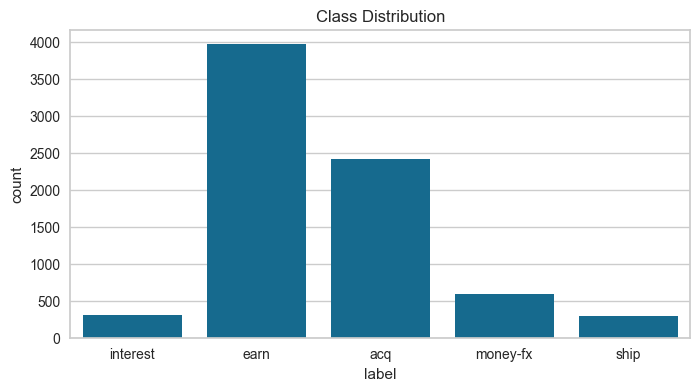

In [11]:
plt.figure(figsize=(8, 4))
sns.countplot(x='label', data=df)
plt.title("Class Distribution")
plt.show()

The dataset is clearly imbalanced.
The **EARN** category dominates, reflecting the high frequency of earnings-related news.
Topics such as **SHIP** and **INTEREST** are more specialized and less frequent.
This imbalance motivates the use of **macro-averaged F1-score** for evaluation or the usage of **Upsampling/Downsampling** techniques during model training (e.g. SMOTE)

## Article Length Analysis

We analyze the distribution of article lengths across topics.
Article length often reflects the nature and complexity of the information conveyed.

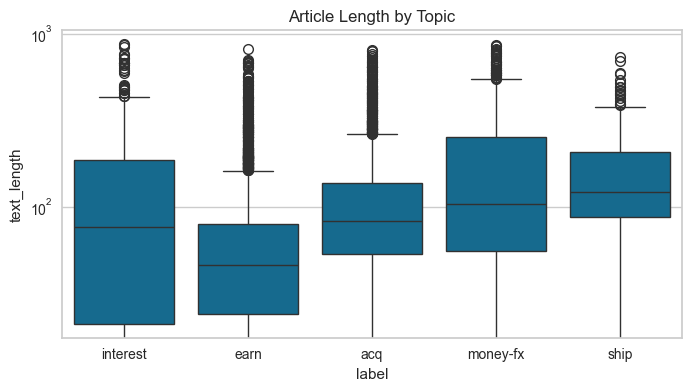

In [12]:
df['text_length'] = df['text'].apply(lambda x: len(x.split()))
plt.figure(figsize=(8, 4))
sns.boxplot(x='label', y='text_length', data=df)
plt.yscale("log")
plt.title("Article Length by Topic")
plt.show()

Most subjects have a wide range of article lengths, but some patterns emerge:
- all have a few long articles compared to their median length
- **EARN** and **INTEREST** articles are generally concise
- **MONEY-FX**, **ACQ**, and **SHIP** articles tend to be longer on average 

Differences in length and structure may influence model behavior.

## Descriptive Analysis / Lexical Characteristics

TF-IDF (Term Frequency–Inverse Document Frequency) is a common technique
used to identify words that are important for a document relative to a
collection of documents.
- **Term Frequency (TF)** increases with the number of times a word appears
  in a document.
- **Inverse Document Frequency (IDF)** decreases the importance of words
  that appear in many documents (e.g. "company", "market").

As a result, TF-IDF highlights words that are **frequent in a given topic**
but **rare across other topics**, making them useful for topic
characterization.

To analyze the vocabulary of each topic, we:
1. Convert all articles into a TF-IDF document–term matrix
2. Group documents by topic
3. Compute the **average TF-IDF score per word within each topic**
4. Extract the top-scoring words as representative keywords

In [13]:
tfidf = TfidfVectorizer(
    stop_words="english",
    max_df=0.9,   # remove very common words
    min_df=10     # keep words appearing in at least 10 documents
)
X = tfidf.fit_transform(df['text'].tolist())
feature_names = np.array(tfidf.get_feature_names_out())

top_terms = {}
for topic in TARGET_TOPICS:
    idx = (df['label'] == topic).values
    mean_tfidf = X[idx].mean(axis=0).A1
    top_terms[topic] = feature_names[mean_tfidf.argsort()[-10:]][::-1] # top 10 terms per topic

top_terms

{'money-fx': array(['dollar', 'said', 'bank', 'yen', 'stg', 'currency', 'market',
        'exchange', 'japan', 'central'], dtype=object),
 'ship': array(['said', 'gulf', 'port', 'ships', 'iran', 'shipping', 'iranian',
        'strike', 'oil', 'tonnes'], dtype=object),
 'interest': array(['pct', 'rate', 'bank', 'rates', 'said', 'prime', 'banks',
        'effective', 'lending', 'market'], dtype=object),
 'acq': array(['said', 'shares', 'company', 'dlrs', 'corp', 'pct', 'mln', 'stock',
        'offer', 'group'], dtype=object),
 'earn': array(['vs', 'cts', 'mln', '000', 'loss', 'net', 'shr', 'dlrs', 'profit',
        'revs'], dtype=object)}

The extracted TF-IDF keywords reflect the semantic focus of each topic.
- Foreign exchange articles emphasize currencies and monetary authorities (*dollar*, *yen*, *exchange*) 
- Shipping articles focus on logistics and geopolitical disruptions (*port*, *ships*, *gulf*)
- Interest rate coverage is dominated by monetary policy terminology (*rate*, *prime*, *lending*)
- Mergers and acquisitions highlight corporate transactions (*shares*, *offer*)
- Earnings reports are characterized by financial performance metrics (*profit*, *loss*, *revs*)

Some generic news terms (e.g. *said*) appear across multiple topics.

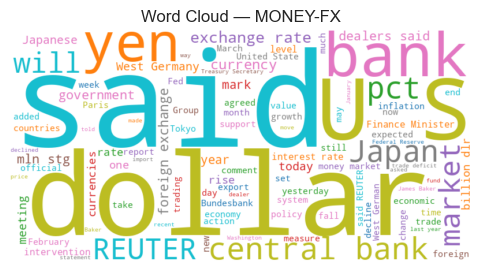

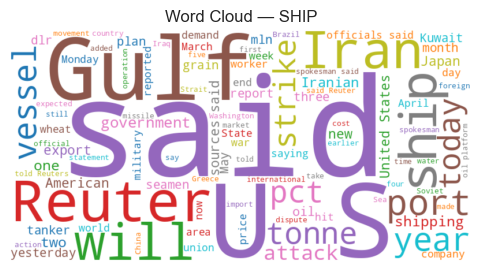

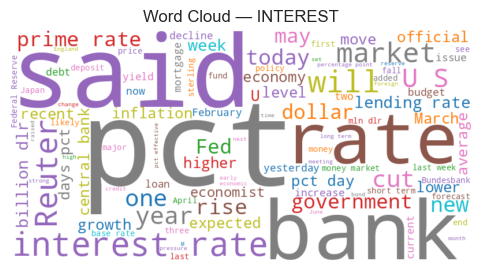

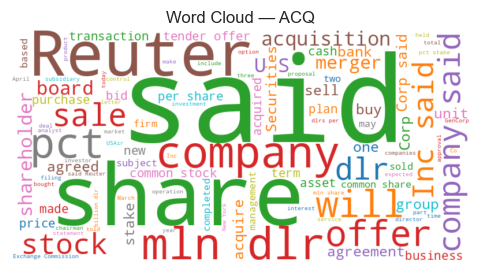

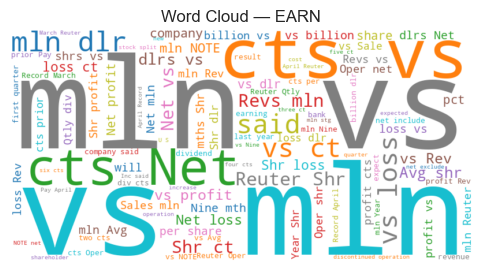

In [14]:
# Generate a word cloud for each topic
for topic in TARGET_TOPICS:
    text = " ".join(df[df['label'] == topic]['text'].tolist())
    wc = WordCloud(width=800,  height=400,  background_color='white',  max_words=100, colormap='tab10').generate(text)
    plt.figure(figsize=(6, 3))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(f"Word Cloud — {topic.upper()}")
    plt.show()

These word clouds visualize the most frequent and relevant terms for each topic. 
The larger the word, the more frequently it appears in the corpus of that category. 
They provide an intuitive view of the semantic focus of each class:

## Vocabulary size per topic


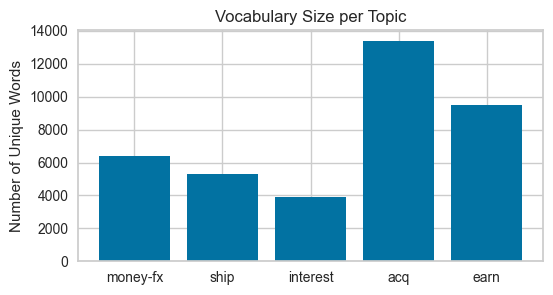

In [15]:
vocab_sizes = {}
for topic in TARGET_TOPICS:
    texts = df[df['label'] == topic]['text'].tolist()
    vectorizer = TfidfVectorizer(stop_words='english')
    X_topic = vectorizer.fit_transform(texts)
    vocab_sizes[topic] = len(vectorizer.get_feature_names_out())

plt.figure(figsize=(6, 3))
plt.bar(vocab_sizes.keys(), vocab_sizes.values())
plt.title("Vocabulary Size per Topic")
plt.ylabel("Number of Unique Words")
plt.show()

`acq` and `earn` are the topics containing the most different words with more than 10 000, compared to the 4 000 of `money-fx`, `ship` and `interest`

## Visualize Word Frequency Distribution

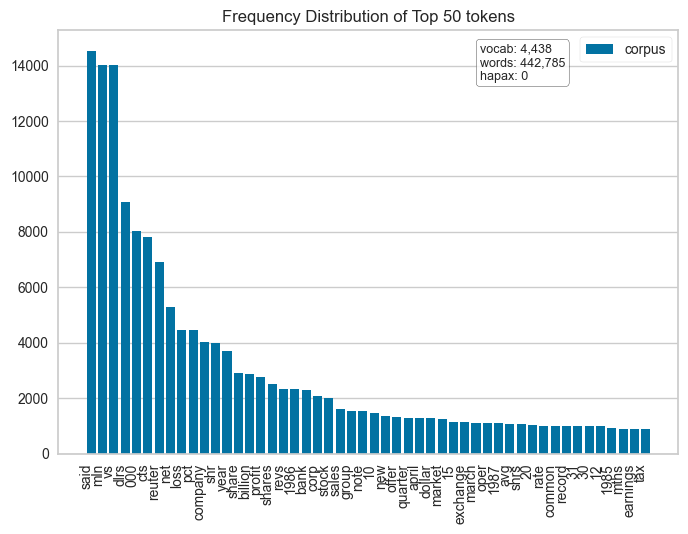

<Axes: title={'center': 'Frequency Distribution of Top 50 tokens'}>

In [16]:
vectorizer = CountVectorizer(stop_words='english', min_df=10)
X_counts = vectorizer.fit_transform(df['text'])

features = vectorizer.get_feature_names_out()
visualizer = FreqDistVisualizer(features=features, orient='v')
visualizer.fit(X_counts)
visualizer.show()

## Lexical Overlap Between Topics

In real-world NLP systems, classification errors often arise from overlapping vocabulary
between categories. We quantify lexical similarity between topics using their most
representative TF-IDF terms.

In [17]:
# Jaccard similarity : intersection over union of top words between topics
def jaccard_similarity(a, b):
    return len(a & b) / len(a | b)

overlap_matrix = pd.DataFrame(index=TARGET_TOPICS, columns=TARGET_TOPICS, dtype=float)

top_words_per_topic = {k: set(v[:30]) for k, v in top_terms.items()}

for t1, t2 in combinations(TARGET_TOPICS, 2):
    sim = jaccard_similarity(top_words_per_topic[t1], top_words_per_topic[t2])
    overlap_matrix.loc[t1, t2] = sim
    overlap_matrix.loc[t2, t1] = sim

np.fill_diagonal(overlap_matrix.values, 1.0)
overlap_matrix

,money-fx,ship,interest,acq,earn
money-fx,1.000000,0.052632,0.176471,0.052632,0.000000
ship,0.052632,1.000000,0.052632,0.052632,0.000000
interest,0.176471,0.052632,1.000000,0.111111,0.000000
acq,0.052632,0.052632,0.111111,1.000000,0.111111
earn,0.000000,0.000000,0.000000,0.111111,1.000000


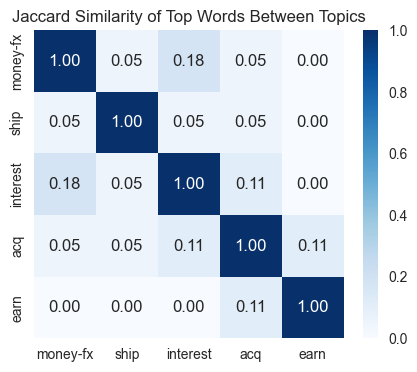

In [18]:
plt.figure(figsize=(5, 4))
sns.heatmap(overlap_matrix.astype(float), annot=True, cmap='Blues', fmt=".2f")
plt.title("Jaccard Similarity of Top Words Between Topics")
plt.title("Jaccard Similarity of Top Words Between Topics")
plt.show()

Shows the proportion of shared articles between topics (0 = no overlap, 1 = full overlap)
- Low off-diagonal values: topics mostly independent.
- Notable overlaps: money-fx & interest (~0.18), acq & interest / earn (~0.11)
- Zero overlap: money-fx & earn, ship & earn

Most topics are distinct, some financial topics slightly overlap.

## Named Entity Recognition Analysis

We perform Named Entity Recognition (NER) to identify and categorize entities mentioned in the articles.
Financial text classification is strongly driven by entities such as: companies ,countries ,institutions ,monetary values.
NER provides an additional semantic layer beyond bag-of-words features.

In [19]:
nlp = spacy.load("en_core_web_sm")
TARGET_ENTITY_TYPES = ['ORG', 'PERSON', 'MONEY']

# Apply NER to all documents
def extract_entities(texts):
    entities = []
    for doc in nlp.pipe(texts, batch_size=32, disable=["tagger", "parser"]):
        entities.extend([(ent.text, ent.label_) for ent in doc.ents if ent.label_ in TARGET_ENTITY_TYPES])
    return entities

all_entities = extract_entities(df['text'].tolist())

# Convert to DataFrame for analysis
entities_df = pd.DataFrame(all_entities, columns=['entity', 'label'])

# Count entities by type
entity_counts = entities_df['label'].value_counts()
print("Top entity types (ORG, PERSON, MONEY):\n", entity_counts)

# Optional: top 10 entities per type
top_entities_per_type = entities_df.groupby('label')['entity'].apply(lambda x: x.value_counts().head(10))
print("\nTop entities per type:\n", top_entities_per_type)

/Users/tomcuel/.venvs/global_env/lib/python3.11/site-packages/spacy/pipeline/lemmatizer.py:188: UserWarning: [W108] The rule-based lemmatizer did not find POS annotation for one or more tokens. Check that your pipeline includes components that assign token.pos, typically 'tagger'+'attribute_ruler' or 'morphologizer'.
  warnings.warn(Warnings.W108)


Top entity types (ORG, PERSON, MONEY):
 label
ORG       28813
PERSON     9124
MONEY      2333
Name: count, dtype: int64

Top entities per type:
 label                                         
MONEY   one cent                                    29
        150 yen                                     27
        140 yen                                     10
        four cents                                   9
        100 francs                                   8
        145 yen                                      8
        five cents                                   7
        below 150 yen                                7
        4.3 billion                                  7
        144.70 yen                                   6
ORG     cts                                       5323
        Reuters                                    216
        Fed                                        191
        USAir                                      177
        Bundesbank                    

## Sentiment Analysis

explore sentiment distribution across topics, only a basic sentiment analysis is performed there

In [20]:
nltk.download('vader_lexicon')
sia = SentimentIntensityAnalyzer()

# Compute sentiment scores
df['sentiment'] = df['text'].apply(lambda x: sia.polarity_scores(x)['compound'])

# Classify sentiment as positive, neutral, or negative
def sentiment_label(score):
    if score > 0.05:
        return 'positive'
    elif score < -0.05:
        return 'negative'
    else:
        return 'neutral'
df['sentiment_label'] = df['sentiment'].apply(sentiment_label)

sentiment_counts = df['sentiment_label'].value_counts(normalize=True)
print("Overall sentiment distribution:\n", sentiment_counts)

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/tomcuel/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


Overall sentiment distribution:
 sentiment_label
positive    0.566895
neutral     0.237556
negative    0.195549
Name: proportion, dtype: float64


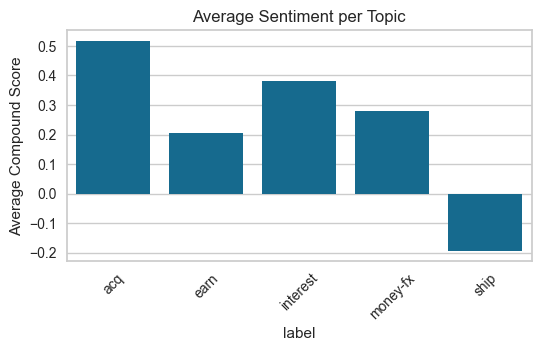

In [21]:
sentiment_per_topic = df.groupby('label')['sentiment'].mean()
plt.figure(figsize=(6,3))
sns.barplot(x=sentiment_per_topic.index, y=sentiment_per_topic.values)
plt.title("Average Sentiment per Topic")
plt.ylabel("Average Compound Score")
plt.xticks(rotation=45)
plt.show()

## Articles classification

Developping the full classification pipeline integrating preprocessing, feature extraction, model training, and evaluation.

## Text Preprocessing 

Clean the text data by lowering case, removing punctuation, stopwords, and lemmatizing words to their base forms. It won't be used there since models like TF-IDF and transformers can handle raw text directly and do it internally.

## Train / Test Split

We perform a stratified split to preserve topic proportions. I could have used the dataset split also or integrate a train/val/test split (but it will have requires a bit more code lines to write)

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    df['text'],
    df['label'],
    test_size=0.2,
    stratify=df['label'],
    random_state=RANDOM_STATE
)
y_train = y_train.to_numpy()
y_test = y_test.to_numpy()

## Feature Extraction

We will use different feature extraction techniques.

- **Traditional: TF-IDF Vectorization**  
  Converts documents into sparse vectors representing the importance of words in each document, normalized by their frequency in the corpus.

In [23]:
vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    max_df=0.9,
    min_df=5, 
    stop_words='english'
)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

- **TD-IDF Vectorization only on first sentences**  
    making a test only the first sentence of each document, since early sentences can sometinmes capture the main topic and a short resume of the document, it could be interesting to see how models perform on that truncated input, balancing speed and performance.

In [24]:
nltk.download('punkt')
def first_n_sentences(text, n=3):
    return " ".join(sent_tokenize(text)[:n])

df['lead_text'] = df['text'].apply(first_n_sentences)

X_train_l, X_test_l, y_train_l, y_test_l = train_test_split(
    df['lead_text'], df['label'],
    stratify=df['label'],
    test_size=0.2,
    random_state=RANDOM_STATE
)

X_train_l_tfidf = vectorizer.fit_transform(X_train_l)
X_test_l_tfidf = vectorizer.transform(X_test_l)

[nltk_data] Downloading package punkt to /Users/tomcuel/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


- **Static Word Embeddings: Word2Vec**  
    Each word is represented by a fixed dense vector capturing semantic meaning. Words that are semantically similar have similar vectors. Going from "man" to "woman" is the same as going from "king" to "queen".
    Document vectors are obtained by averaging the word vectors.

In [25]:
w2v = api.load("word2vec-google-news-300") # Load pre-trained Word2Vec embeddings

def document_vector(doc):
    words = [w for w in doc.lower().split() if w in w2v]
    if len(words) == 0:
        return np.zeros(w2v.vector_size)
    return np.mean(w2v[words], axis=0)

X_train_w2v = np.array([document_vector(text) for text in X_train])
X_test_w2v = np.array([document_vector(text) for text in X_test])

- **Modern Contextual Embeddings: Transformer-based models**  
    Use pre-trained transformer models to obtain context-aware embeddings for each document. Here we use Sentence-BERT (`all-MiniLM-L6-v2`) (long to compute).

1. Load model and tokenizer

In [26]:
MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModel.from_pretrained(MODEL_NAME)
model.eval()

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

/Users/tomcuel/.venvs/global_env/lib/python3.11/site-packages/keras/src/export/tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(30522, 384, padding_idx=0)
    (position_embeddings): Embedding(512, 384)
    (token_type_embeddings): Embedding(2, 384)
    (LayerNorm): LayerNorm((384,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-5): 6 x BertLayer(
        (attention): BertAttention(
          (self): BertSdpaSelfAttention(
            (query): Linear(in_features=384, out_features=384, bias=True)
            (key): Linear(in_features=384, out_features=384, bias=True)
            (value): Linear(in_features=384, out_features=384, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=384, out_features=384, bias=True)
            (LayerNorm): LayerNorm((384,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False)


2. Mean pooling function aggregates token embeddings into a single sentence vector using attention-mask aware mean pooling

In [27]:
def mean_pooling(model_output, attention_mask):
    token_embeddings = model_output.last_hidden_state
    input_mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
    return (token_embeddings * input_mask_expanded).sum(1) / input_mask_expanded.sum(1)

3. Encoding function (batched, efficient)

In [28]:
def encode_sentences(texts, batch_size=32):
    embeddings = []

    with torch.no_grad():
        for i in range(0, len(texts), batch_size):
            batch = texts[i:i+batch_size]
            encoded = tokenizer(batch, padding=True, truncation=True, max_length=512, return_tensors="pt")

            model_output = model(**encoded)
            batch_embeddings = mean_pooling(model_output, encoded["attention_mask"])
            embeddings.append(batch_embeddings.cpu())

    return torch.cat(embeddings, dim=0)

X_train_transformer = encode_sentences(X_train.tolist(), batch_size=32).numpy()
X_test_transformer = encode_sentences(X_test.tolist(), batch_size=32).numpy()

Encode the y_train and y_test labels using `LabelEncoder` from sklearn.

# Upsampling Classification Method

Since those are imbalances classes, we could potentially fix this using `SMOTE`

In [29]:
smote = SMOTE(random_state=RANDOM_STATE)
X_train_tfidf_up, y_train_up = smote.fit_resample(X_train_tfidf, y_train)
X_train_l_tfidf_up, y_train_l_up = smote.fit_resample(X_train_l_tfidf, y_train_l)
X_train_w2v_up, y_train_up = smote.fit_resample(X_train_w2v, y_train)
X_train_transformer_up, y_train_up = smote.fit_resample(X_train_transformer, y_train)

encoder = LabelEncoder()
y_train_up_enc = encoder.fit_transform(y_train_up)
y_test_enc = encoder.transform(y_test)

encoder_l = LabelEncoder()
y_train_l_up_enc = encoder_l.fit_transform(y_train_l_up)
y_test_l_enc = encoder_l.transform(y_test_l)

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


we then verify the new class distribution after upsampling.

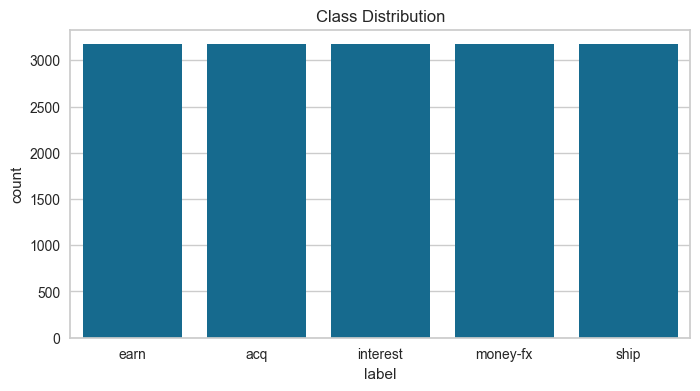

In [30]:
plt.figure(figsize=(8, 4))
sns.countplot(x='label', data=pd.DataFrame({'label': encoder.inverse_transform(y_train_up_enc)}))
plt.title("Class Distribution")
plt.show()

#### Models

- **Logistic Regression**: models the probability of each class using a logistic function, effective for high-dimensional sparse data
- **Linear SVM**: finds the optimal hyperplane that separates classes with maximum margin, efficient for text data
- **SVM (RBF)**: uses a radial basis function kernel to capture non-linear decision boundaries
- **Random Forest**: random split the features and build multiple decision trees to improve classification accuracy and control overfitting
- **XGBoost**: an optimized gradient boosting algorithm that builds an ensemble of weak learners (decision trees) to create a strong predictive model
- **KNN**: classifies based on the majority class among the k-nearest neighbors in the feature space
- **Decision Tree**: a tree-based model that splits the data based on feature values to make predictions
- **SGD Classifier**: uses stochastic gradient descent (taking random subsets of data for each update) to efficiently train linear models on large datasets

In [31]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Linear SVM": LinearSVC(random_state=RANDOM_STATE),       # Fast linear SVM
    "SVM (RBF)": SVC(random_state=RANDOM_STATE),              # Non-linear SVM with RBF kernel
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE),
    "XGBoost": XGBClassifier(eval_metric='mlogloss', random_state=RANDOM_STATE),
    "KNN": KNeighborsClassifier(n_neighbors=5),               # Simple distance-based classifier
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "SGD Classifier": SGDClassifier(max_iter=1000, tol=1e-3, random_state=RANDOM_STATE)
}

#### Features 
- **TF-IDF**
- **TF-IDF on first sentences**
- **Word2Vec**
- **Transformer Embeddings**

In [32]:
features = {
    "TF-IDF (full text)": (X_train_tfidf_up, X_test_tfidf),
    "TF-IDF (lead text)": (X_train_l_tfidf_up, X_test_l_tfidf),
    "Word2Vec": (X_train_w2v_up, X_test_w2v),
    "Transformer embeddings": (X_train_transformer_up, X_test_transformer)
}

#### Note about Hyperparameter Tuning

I know that is maybe the most important part of building a good model, but due to time constraints I didn't wanted to spend too much time, looking at my computer for hours doing the `optuna` hyperparameter optimization, so results are to be taken with a grain of salt, since models performance could be significantly improved with a proper hyperparameter search and change drastically the final ranking of models.

It will be done on the Deep Learning part of the notebook (for the MLP as an example)

#### Training and Evaluation Loop (store results for each combination of model and feature set)

Evaluation metrics:
- **Accuracy**: overall correctness of the model $=\frac{TP + TN}{TP + TN + FP + FN}$
- **Precision**: correctness of positive predictions $=\frac{TP}{TP + FP}$
- **Recall**: ability to find all positive instances $=\frac{TP}{TP + FN}$
- **F1 Score (Macro)**: harmonic mean of precision and recall, averaged across classes $=2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$

In [34]:
results = []
for feature_name, (X_train_feat, X_test_feat) in features.items():
    print(f"Evaluating feature set: {feature_name}")
    for name, model in models.items():
        print(f"  Training model: {name}")
        # Train the model
        model.fit(X_train_feat, y_train_up_enc if "lead text" not in feature_name else y_train_l_up_enc)

        # Make predictions on the test set
        preds = model.predict(X_test_feat)

        # Compute evaluation metrics
        acc = accuracy_score(y_test_enc if "lead text" not in feature_name else y_test_l_enc, preds)
        f1 = f1_score(y_test_enc if "lead text" not in feature_name else y_test_l_enc, preds, average="macro")     
        precision = precision_score(y_test_enc if "lead text" not in feature_name else y_test_l_enc, preds, average="macro")
        recall = recall_score(y_test_enc if "lead text" not in feature_name else y_test_l_enc, preds, average="macro")
        
        results.append({
            "Model": name,
            "Feature Set": feature_name,
            "Accuracy": acc,
            "F1 Macro": f1,
            "Precision": precision,
            "Recall": recall
        })

Evaluating feature set: TF-IDF (full text)
  Training model: Logistic Regression
  Training model: Linear SVM
  Training model: SVM (RBF)
  Training model: Random Forest
  Training model: XGBoost
  Training model: KNN
  Training model: Decision Tree
  Training model: SGD Classifier
Evaluating feature set: TF-IDF (lead text)
  Training model: Logistic Regression
  Training model: Linear SVM
  Training model: SVM (RBF)
  Training model: Random Forest
  Training model: XGBoost
  Training model: KNN
  Training model: Decision Tree
  Training model: SGD Classifier
Evaluating feature set: Word2Vec
  Training model: Logistic Regression
  Training model: Linear SVM
  Training model: SVM (RBF)
  Training model: Random Forest
  Training model: XGBoost
  Training model: KNN
  Training model: Decision Tree
  Training model: SGD Classifier
Evaluating feature set: Transformer embeddings
  Training model: Logistic Regression
  Training model: Linear SVM
  Training model: SVM (RBF)
  Training model: R

In [35]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="F1 Macro", ascending=False)
results_df

,Model,Feature Set,Accuracy,F1 Macro,Precision,Recall
23,SGD Classifier,Word2Vec,0.899934,0.847502,0.898471,0.808902
24,Logistic Regression,Transformer embeddings,0.895984,0.829358,0.841567,0.890568
29,KNN,Transformer embeddings,0.883476,0.828855,0.859824,0.805687
21,KNN,Word2Vec,0.886768,0.827326,0.858311,0.803103
26,SVM (RBF),Transformer embeddings,0.891376,0.824376,0.840466,0.879506
1,Linear SVM,TF-IDF (full text),0.894668,0.823717,0.829453,0.878835
7,SGD Classifier,TF-IDF (full text),0.892693,0.822669,0.831103,0.876812
25,Linear SVM,Transformer embeddings,0.890059,0.819722,0.836212,0.874662
0,Logistic Regression,TF-IDF (full text),0.888743,0.819635,0.830232,0.871051
31,SGD Classifier,Transformer embeddings,0.889401,0.818785,0.832000,0.882333


#### Analyse Results of the best model

In [36]:
best_model_name = results_df.iloc[0]['Model']
best_model_feature = results_df.iloc[0]['Feature Set']
print(f"Best Model: {best_model_name} with Feature Set: {best_model_feature}")
best_model_instance = models[best_model_name]
X_train_best, X_test_best = features[best_model_feature]
print(best_model_instance)

Best Model: SGD Classifier with Feature Set: Word2Vec
SGDClassifier(random_state=42)


In [37]:
model.fit(X_train_best, y_train_up_enc)
y_pred_best = best_model_instance.predict(X_test_best)
y_pred = encoder.inverse_transform(y_pred_best)

#### Classification Report

In [38]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         acq       0.94      0.88      0.91       484
        earn       0.88      0.96      0.92       794
    interest       0.82      0.60      0.69        62
    money-fx       0.91      0.74      0.81       119
        ship       0.95      0.87      0.90        60

    accuracy                           0.90      1519
   macro avg       0.90      0.81      0.85      1519
weighted avg       0.90      0.90      0.90      1519



#### Confusion Matrix

In [39]:
cm = confusion_matrix(y_test, y_pred)
print(pd.DataFrame(cm, index=encoder.classes_, columns=encoder.classes_))

          acq  earn  interest  money-fx  ship
acq       425    57         1         0     1
earn       26   765         1         1     1
interest    1    19        37         5     0
money-fx    1    23         6        88     1
ship        1     4         0         3    52


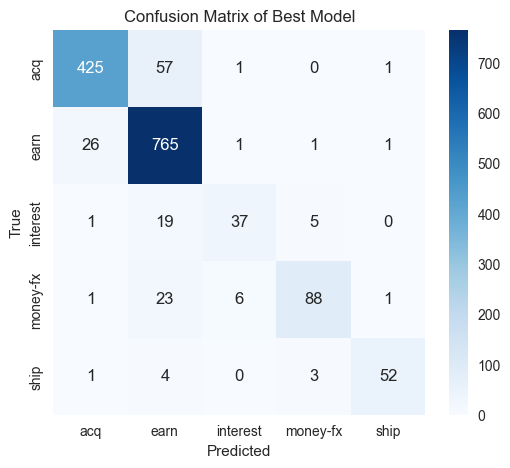

In [40]:
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=encoder.classes_, yticklabels=encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix of Best Model')
plt.show()

#### AUC-ROC Curve

In [41]:
classes = encoder.classes_
y_test_bin = label_binarize(y_test_enc, classes=range(len(classes)))

# y_score = model.predict_proba(X_test_best)
y_score = model.decision_function(X_test_best)

roc_auc = roc_auc_score(y_test_bin, y_score, average="macro", multi_class="ovr")
print("ROC-AUC (macro, OvR):", roc_auc)

ROC-AUC (macro, OvR): 0.9794804223766033


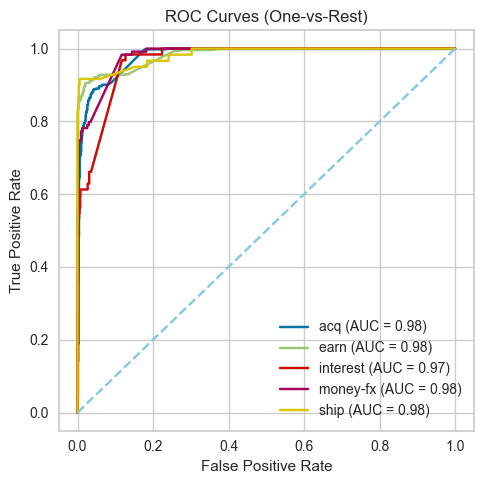

In [42]:
plt.figure(figsize=(5, 5))
for i, class_name in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{class_name} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves (One-vs-Rest)")
plt.legend()
plt.tight_layout()
plt.show()

#### Upsampling Model Performance Analysis
The upsampling strategy leads to **strong overall performance** with an accuracy of **90%** and a **macro F1-score of 0.85**, indicating good balance across classes despite the original class imbalance.
- **Majority classes** (`acq`, `earn`) 
    show excellent performance, with high precision and recall, confirming that upsampling does not degrade performance on frequent categories.
- **Minority classes benefit from upsampling**:  
    `ship` and `money-fx` achieve strong F1-scores (≈0.90 and 0.81), showing effective learning of previously underrepresented patterns.
- **`interest` remains the most challenging class**:  
    While precision is reasonable (0.82), recall is lower (0.60), indicating confusion mainly with `earn` and `money-fx`, as seen in the confusion matrix.

The confusion matrix confirms that most errors occur between semantically close financial categories, which is expected in real-world news classification.

Overall, upsampling improves minority-class recognition without harming majority classes, making it an effective strategy for this task.

# Loss Penalization Classification Method

Since those are imbalances classes, after exploring Upsampling, we could also try to penalize the loss function during training using class weights inversely proportional to class frequencies.
It also to preserve all data without synthetically generating new samples as in SMOTE.

In [43]:
encoder = LabelEncoder()
y_train_enc = encoder.fit_transform(y_train)
y_test_enc = encoder.transform(y_test)

encoder_l = LabelEncoder()
y_train_l_enc = encoder_l.fit_transform(y_train_l)
y_test_l_enc = encoder_l.transform(y_test_l)

In [44]:
classes = np.unique(y_train_enc)
class_weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train_enc)
class_weight_dict = dict(zip(classes, class_weights))
print("Class weights:", class_weight_dict)

Class weights: {0: 0.6269349845201239, 1: 0.38291837377875826, 2: 4.899193548387097, 3: 2.5418410041841004, 4: 5.105042016806722}


In [45]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, class_weight=class_weight_dict),
    "Linear SVM": LinearSVC(random_state=RANDOM_STATE, class_weight=class_weight_dict),       # Fast linear SVM
    "SVM (RBF)": SVC(random_state=RANDOM_STATE, class_weight=class_weight_dict),              # Non-linear SVM with RBF kernel
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, class_weight=class_weight_dict),
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE, class_weight=class_weight_dict),
    "SGD Classifier": SGDClassifier(max_iter=1000, tol=1e-3, random_state=RANDOM_STATE, class_weight=class_weight_dict)
}

In [46]:
features = {
    "TF-IDF (full text)": (X_train_tfidf, X_test_tfidf),
    "TF-IDF (lead text)": (X_train_l_tfidf, X_test_l_tfidf),
    "Word2Vec": (X_train_w2v, X_test_w2v),
    "Transformer embeddings": (X_train_transformer, X_test_transformer)
}

In [47]:
results = []
for feature_name, (X_train_feat, X_test_feat) in features.items():
    print(f"Evaluating feature set: {feature_name}")
    for name, model in models.items():
        print(f"  Training model: {name}")
        # Train the model
        model.fit(X_train_feat, y_train_enc if "lead text" not in feature_name else y_train_l_enc)

        # Make predictions on the test set
        preds = model.predict(X_test_feat)

        # Compute evaluation metrics
        acc = accuracy_score(y_test_enc if "lead text" not in feature_name else y_test_l_enc, preds)
        f1 = f1_score(y_test_enc if "lead text" not in feature_name else y_test_l_enc, preds, average="macro")     
        precision = precision_score(y_test_enc if "lead text" not in feature_name else y_test_l_enc, preds, average="macro")
        recall = recall_score(y_test_enc if "lead text" not in feature_name else y_test_l_enc, preds, average="macro")
        
        results.append({
            "Model": name,
            "Feature Set": feature_name,
            "Accuracy": acc,
            "F1 Macro": f1,
            "Precision": precision,
            "Recall": recall
        })

Evaluating feature set: TF-IDF (full text)
  Training model: Logistic Regression
  Training model: Linear SVM
  Training model: SVM (RBF)
  Training model: Random Forest
  Training model: Decision Tree
  Training model: SGD Classifier
Evaluating feature set: TF-IDF (lead text)
  Training model: Logistic Regression
  Training model: Linear SVM
  Training model: SVM (RBF)
  Training model: Random Forest
  Training model: Decision Tree
  Training model: SGD Classifier
Evaluating feature set: Word2Vec
  Training model: Logistic Regression
  Training model: Linear SVM
  Training model: SVM (RBF)
  Training model: Random Forest
  Training model: Decision Tree
  Training model: SGD Classifier
Evaluating feature set: Transformer embeddings
  Training model: Logistic Regression
  Training model: Linear SVM
  Training model: SVM (RBF)
  Training model: Random Forest
  Training model: Decision Tree
  Training model: SGD Classifier


In [48]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="F1 Macro", ascending=False)
results_df

,Model,Feature Set,Accuracy,F1 Macro,Precision,Recall
5,SGD Classifier,TF-IDF (full text),0.898618,0.834936,0.875706,0.847567
23,SGD Classifier,Transformer embeddings,0.894668,0.833635,0.840716,0.859000
19,Linear SVM,Transformer embeddings,0.894668,0.829763,0.839623,0.889625
18,Logistic Regression,Transformer embeddings,0.893351,0.827497,0.837267,0.888176
20,SVM (RBF),Transformer embeddings,0.888084,0.822331,0.835742,0.881382
0,Logistic Regression,TF-IDF (full text),0.886109,0.818223,0.830458,0.870258
1,Linear SVM,TF-IDF (full text),0.893351,0.816387,0.828031,0.863301
13,Linear SVM,Word2Vec,0.886109,0.814563,0.824496,0.864771
14,SVM (RBF),Word2Vec,0.877551,0.814493,0.822631,0.875099
11,SGD Classifier,TF-IDF (lead text),0.890718,0.813794,0.856819,0.827086


In [49]:
best_model_name = results_df.iloc[0]['Model']
best_model_feature = results_df.iloc[0]['Feature Set']
print(f"Best Model: {best_model_name} with Feature Set: {best_model_feature}")
best_model_instance = models[best_model_name]
X_train_best, X_test_best = features[best_model_feature]
print(best_model_instance)

Best Model: SGD Classifier with Feature Set: TF-IDF (full text)
SGDClassifier(class_weight={0: 0.6269349845201239, 1: 0.38291837377875826,
                            2: 4.899193548387097, 3: 2.5418410041841004,
                            4: 5.105042016806722},
              random_state=42)


In [50]:
model.fit(X_train_best, y_train_enc)
y_pred_best = best_model_instance.predict(X_test_best)
y_pred = encoder.inverse_transform(y_pred_best)

In [51]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         acq       0.97      0.88      0.93       484
        earn       0.98      0.92      0.95       794
    interest       0.95      0.58      0.72        62
    money-fx       0.48      0.97      0.64       119
        ship       1.00      0.88      0.94        60

    accuracy                           0.90      1519
   macro avg       0.88      0.85      0.83      1519
weighted avg       0.94      0.90      0.91      1519



In [52]:
cm = confusion_matrix(y_test, y_pred)
print(pd.DataFrame(cm, index=encoder.classes_, columns=encoder.classes_))

          acq  earn  interest  money-fx  ship
acq       428    10         0        46     0
earn       11   733         0        50     0
interest    0     0        36        26     0
money-fx    0     2         2       115     0
ship        1     2         0         4    53


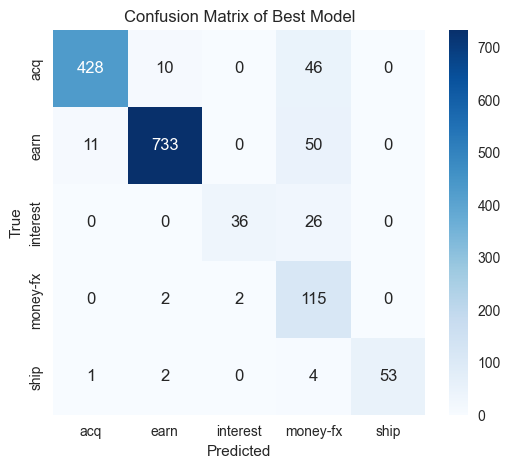

In [53]:
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=encoder.classes_, yticklabels=encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix of Best Model')
plt.show()

#### AUC-ROC Curve

In [54]:
classes = encoder.classes_
y_test_bin = label_binarize(y_test_enc, classes=range(len(classes)))

# y_score = model.predict_proba(X_test_best)
y_score = model.decision_function(X_test_best)

roc_auc = roc_auc_score(y_test_bin, y_score, average="macro", multi_class="ovr")
print("ROC-AUC (macro, OvR):", roc_auc)

ROC-AUC (macro, OvR): 0.9807989357213461


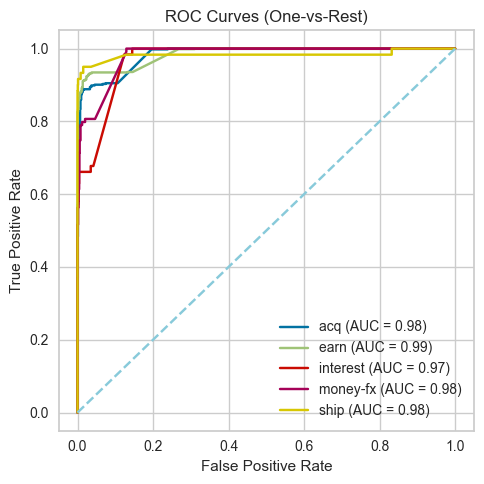

In [55]:
plt.figure(figsize=(5, 5))
for i, class_name in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{class_name} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves (One-vs-Rest)")
plt.legend()
plt.tight_layout()
plt.show()

#### Class-Weighted Model Performance Analysis

Using loss penalization via class weights yields an overall accuracy of 90%, comparable to the upsampling approach, but with different error characteristics.
- **Majority classes** (`acq`, `earn`): 
    very high precision (≥ 0.97) and strong recall, indicates the model is highly confident when predicting these classes and makes few false positives.
- **Minority classes**
    - `interest`: high precision (0.95) but **low recall (0.58)**.
    The model is conservative: when it predicts `interest` it is usually correct, but it misses many true interest articles, often misclassified as `money-fx`.
    - `money-fx`: extremely high recall (0.97) but **very low precision (0.48)**.
    The confusion matrix shows many articles from other financial classes (`acq`, `earn`, `interest`) are incorrectly predicted as `money-fx`.
    - `ship`: near-perfect precision (1.00) and strong recall (0.88), indicating clear lexical separation.

Overall, class weighting **shifts the model toward recall for some minority classes**, at the cost of increased false positives, especially for `money-fx`.

## Comparaison of both methods on their respective best models

- **Upsampling** produces **more balanced decision boundaries**, leading to better macro-level performance and more stable minority-class predictions.
- **Class weighting** is effective when **recall is critical**, but may distort predictions by over-favoring certain classes, as seen with `money-fx`.

# Deep Learning Classification Method

## Simple Feedforward Neural Network (MLP)

For **fixed-size embeddings** like TF-IDF or averaged Word2Vec/transformer embeddings, focusing here on the transformer embeddings.

#### Convert to torch tensors and create Datasets

In [56]:
X_train_tensor = torch.tensor(X_train_transformer_up, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_up_enc, dtype=torch.long)
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)

X_test_tensor = torch.tensor(X_test_transformer, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test_enc, dtype=torch.long)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

#### Model Definition

In [57]:
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_layers, output_dim, dropout_rate=0.3):
        super().__init__()
        layers = []
        prev = input_dim
        for h in hidden_layers:
            layers.append(nn.Linear(prev, h))
            layers.append(nn.BatchNorm1d(h))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout_rate))
            prev = h
        
        # Output layer (no activation here if using CrossEntropy)
        layers.append(nn.Linear(prev, output_dim))
        self.net = nn.Sequential(*layers)

        self._init_weights()

    def _init_weights(self):
        idx_hidden = 0
        for m in self.net:
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity="relu") # He init
                nn.init.zeros_(m.bias)
                idx_hidden += 1
    
    def forward(self, x):
        return self.net(x)

#### Hyperparameters Tuning with Optuna

In [58]:
def objective(trial, epochs, input_dim, num_classes, train_dataset, device):
    # Hyperparameters to search
    n_layers = trial.suggest_int("n_layers", 2, 5)
    hidden_layers = [trial.suggest_int(f"n_units_l{i}", 64, 384) for i in range(n_layers)]
    batch_size = trial.suggest_categorical("batch_size", [16, 32, 64, 128])
    dropout_rate = trial.suggest_float(f"dropout_rate", 0.0, 0.6)
    lr = trial.suggest_float("learning_rate", 1e-4, 0.1, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-2, log=True)
    patience = trial.suggest_int("patience", 3, 10)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    model = MLP(input_dim, hidden_layers, num_classes, dropout_rate=dropout_rate)
    model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=patience)

    best_loss = float('inf')
    for epoch in range(epochs):
        model.train()
        total_loss = 0.0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * X_batch.size(0)

        avg_train_loss = total_loss / len(train_loader.dataset)
        scheduler.step(avg_train_loss)

        if (epoch + 1) % 5 == 0:
            print(f"Trial {trial.number} | Epoch {epoch+1}/{epochs} | Train Loss: {avg_train_loss:.4f}")

        # Early stopping based on training loss
        if avg_train_loss < best_loss:
            best_loss = avg_train_loss
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                break
            
    return best_loss

In [59]:
input_dim = X_train_transformer.shape[1]
num_classes = len(encoder.classes_)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
EPOCHS = 20
N_TRIALS = 10
obj = partial(objective, epochs=EPOCHS, input_dim=input_dim, num_classes=num_classes, train_dataset=train_dataset, device=device)
study = optuna.create_study(direction="minimize", pruner=optuna.pruners.MedianPruner())
study.optimize(obj, n_trials=N_TRIALS)
print("Best Trial:")
trial = study.best_trial
print(f"  Value: {trial.value}")
print("  Params: ")
for key, value in trial.params.items():
    print(f"    {key}: {value}")

[I 2026-02-01 22:27:15,680] A new study created in memory with name: no-name-36d5fc84-ac94-4799-8de8-48e2358d7095


Trial 0 | Epoch 5/20 | Train Loss: 0.2334
Trial 0 | Epoch 10/20 | Train Loss: 0.1959
Trial 0 | Epoch 15/20 | Train Loss: 0.1814


[I 2026-02-01 22:27:33,927] Trial 0 finished with value: 0.17177621379149494 and parameters: {'n_layers': 3, 'n_units_l0': 137, 'n_units_l1': 289, 'n_units_l2': 369, 'batch_size': 32, 'dropout_rate': 0.21556436537969137, 'learning_rate': 0.0002061673944960922, 'weight_decay': 2.260404181558552e-06, 'patience': 4}. Best is trial 0 with value: 0.17177621379149494.


Trial 0 | Epoch 20/20 | Train Loss: 0.1718
Trial 1 | Epoch 5/20 | Train Loss: 0.3879
Trial 1 | Epoch 10/20 | Train Loss: 0.3058
Trial 1 | Epoch 15/20 | Train Loss: 0.2706


[I 2026-02-01 22:28:24,330] Trial 1 finished with value: 0.24411834684684003 and parameters: {'n_layers': 5, 'n_units_l0': 172, 'n_units_l1': 246, 'n_units_l2': 124, 'n_units_l3': 199, 'n_units_l4': 210, 'batch_size': 16, 'dropout_rate': 0.5002964020281091, 'learning_rate': 0.0005812285394026586, 'weight_decay': 2.1639259590980846e-05, 'patience': 10}. Best is trial 0 with value: 0.17177621379149494.


...

Trial 7 | Epoch 20/20 | Train Loss: 0.1607
Trial 8 | Epoch 5/20 | Train Loss: 0.2190
Trial 8 | Epoch 10/20 | Train Loss: 0.1913
Trial 8 | Epoch 15/20 | Train Loss: 0.1793


[I 2026-02-01 22:29:34,256] Trial 8 finished with value: 0.17698055982702432 and parameters: {'n_layers': 4, 'n_units_l0': 187, 'n_units_l1': 298, 'n_units_l2': 99, 'n_units_l3': 279, 'batch_size': 32, 'dropout_rate': 0.25235253763624393, 'learning_rate': 0.00194565597390882, 'weight_decay': 0.00015828510974297716, 'patience': 9}. Best is trial 7 with value: 0.16044821036357892.


Trial 8 | Epoch 20/20 | Train Loss: 0.1790
Trial 9 | Epoch 5/20 | Train Loss: 0.2406
Trial 9 | Epoch 10/20 | Train Loss: 0.2077
Trial 9 | Epoch 15/20 | Train Loss: 0.1942


[I 2026-02-01 22:30:07,410] Trial 9 finished with value: 0.18051005809362702 and parameters: {'n_layers': 5, 'n_units_l0': 191, 'n_units_l1': 220, 'n_units_l2': 167, 'n_units_l3': 251, 'n_units_l4': 242, 'batch_size': 32, 'dropout_rate': 0.2783855893795867, 'learning_rate': 0.0033885594989371453, 'weight_decay': 0.00036967827491667495, 'patience': 8}. Best is trial 7 with value: 0.16044821036357892.


Trial 9 | Epoch 20/20 | Train Loss: 0.1826
Best Trial:
  Value: 0.16044821036357892
  Params: 
    n_layers: 3
    n_units_l0: 194
    n_units_l1: 182
    n_units_l2: 356
    batch_size: 128
    dropout_rate: 0.15546352820084033
    learning_rate: 0.0005313441770839381
    weight_decay: 5.567796693304826e-06
    patience: 4


#### Extract best hyperparameters 

In [60]:
best_params = trial.params
hidden_layers = [best_params[f"n_units_l{i}"] for i in range(best_params["n_layers"])]
batch_size = best_params["batch_size"]
dropout_rate = best_params["dropout_rate"]
lr = best_params["learning_rate"]
weight_decay = best_params["weight_decay"]
patience = best_params["patience"]

#### Training the best model out of the Hyperparameter Tuning

In [61]:
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

model = MLP(input_dim, hidden_layers, num_classes, dropout_rate)
model = model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=patience)
print(model)

MLP(
  (net): Sequential(
    (0): Linear(in_features=384, out_features=194, bias=True)
    (1): BatchNorm1d(194, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.15546352820084033, inplace=False)
    (4): Linear(in_features=194, out_features=182, bias=True)
    (5): BatchNorm1d(182, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.15546352820084033, inplace=False)
    (8): Linear(in_features=182, out_features=356, bias=True)
    (9): BatchNorm1d(356, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.15546352820084033, inplace=False)
    (12): Linear(in_features=356, out_features=5, bias=True)
  )
)


In [62]:
best_loss = float('inf')
for epoch in range(EPOCHS):
    model.train()
    total_loss = 0.0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * X_batch.size(0)

    avg_train_loss = total_loss / len(train_loader.dataset)
    scheduler.step(avg_train_loss)

    if (epoch + 1) % 5 == 0:
        print(f"Trial {trial.number} | Epoch {epoch+1}/{EPOCHS} | Train Loss: {avg_train_loss:.4f}")

    # Early stopping based on training loss
    if avg_train_loss < best_loss:
        best_loss = avg_train_loss
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            break

Trial 7 | Epoch 5/20 | Train Loss: 0.1918
Trial 7 | Epoch 10/20 | Train Loss: 0.1717
Trial 7 | Epoch 15/20 | Train Loss: 0.1644
Trial 7 | Epoch 20/20 | Train Loss: 0.1621


#### Evaluation 

In [63]:
model.eval()
y_pred_enc = []
for X_batch, _ in test_loader:
    X_batch = X_batch.to(device)
    with torch.no_grad():
        outputs = model(X_batch)
        y_pred_enc.extend(torch.argmax(outputs, dim=1).cpu().numpy())

y_pred = encoder.inverse_transform(y_pred_enc)

#### Classification Report

In [64]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         acq       0.97      0.88      0.92       484
        earn       0.99      0.92      0.95       794
    interest       0.32      0.92      0.47        62
    money-fx       0.95      0.76      0.84       119
        ship       0.95      0.92      0.93        60

    accuracy                           0.90      1519
   macro avg       0.83      0.88      0.82      1519
weighted avg       0.95      0.90      0.91      1519



#### Confusion Matrix

In [65]:
cm = confusion_matrix(y_test, y_pred)
print(pd.DataFrame(cm, index=encoder.classes_, columns=encoder.classes_))

          acq  earn  interest  money-fx  ship
acq       428    10        45         0     1
earn       11   733        50         0     0
interest    0     0        57         5     0
money-fx    1     1        25        90     2
ship        3     0         2         0    55


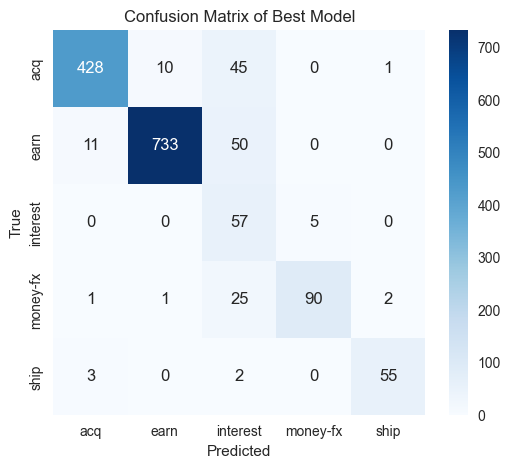

In [66]:
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=encoder.classes_, yticklabels=encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix of Best Model')
plt.show()

#### Comments

The same type of results as before with the two methods (Upsampling and Loss Penalization) are observed here with the MLP model. It's just a bit worst on `interest` with a **low precision of 0.31** and **a f1-score of 0.45** while other classes perform quite well, and even better than before. 

It still doesn't have the same power as more advanced models like transformers but it's performing good.
`interest`and `money-fx` remains the most challenging classes, likely due to their semantic overlap, since the topics are quite close to each other in the financial domain.

## Fine-Tuning Transformer Models

State-of-the-art text classification, I will try a fine-tuning approach using pre-trained transformer models.

In [99]:
X_train, X_test, y_train, y_test = train_test_split(
    df['text'],
    df['label'],
    test_size=0.2,
    stratify=df['label'],
    random_state=RANDOM_STATE
)
y_train = y_train.to_numpy()
y_test = y_test.to_numpy()

#### Load tokenizer + base model (encoder only)

In [100]:
MODEL_NAME = "bert-base-uncased"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
bert = AutoModel.from_pretrained(MODEL_NAME).to(device)

#### Label Encoding

In [101]:
encoder_ft = LabelEncoder()
y_train_ft_enc = encoder_ft.fit_transform(y_train)
y_test_ft_enc = encoder_ft.transform(y_test)
num_classes = len(encoder_ft.classes_)

#### Dataset

In [102]:
class ReutersDataset(torch.utils.data.Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=256):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(self.texts[idx], truncation=True, padding="max_length", max_length=self.max_len, return_tensors="pt")

        return {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "labels": torch.tensor(self.labels[idx])
        }

In [103]:
train_dataset = ReutersDataset(X_train.tolist(), y_train_ft_enc, tokenizer)
test_dataset = ReutersDataset(X_test.tolist(), y_test_ft_enc, tokenizer)

#### DataLoaders

In [104]:
BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

#### Custom classification model (BERT + head)

In [105]:
class BertClassifier(nn.Module):
    def __init__(self, bert_model, num_classes):
        super().__init__()
        self.bert = bert_model
        self.dropout = nn.Dropout(0.3)
        self.classifier = nn.Linear(bert_model.config.hidden_size, num_classes)

        # Freeze BERT parameters
        for param in self.bert.parameters():
            param.requires_grad = False

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls = outputs.last_hidden_state[:, 0, :]
        x = self.dropout(cls)
        logits = self.classifier(x)
        return logits
    
model_ft = BertClassifier(bert, num_classes).to(device)
print(model_ft)

BertClassifier(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, elementwis

#### Loss function with class weights + Optimizer + Scheduler

In [106]:
class_weights = compute_class_weight(class_weight="balanced", classes=np.unique(y_train_enc), y=y_train_enc)
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)
LR = 1e-2
WD = 1e-4
optimizer = optim.AdamW(model_ft.classifier.parameters(), lr=LR, weight_decay=WD)

#### Training Loop

In [107]:
EPOCHS = 3
for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    for batch in train_loader:
        optimizer.zero_grad()

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        logits = model_ft(input_ids, attention_mask)
        loss = criterion(logits, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
    
    print(f"Epoch {epoch+1}/{EPOCHS} — Loss: {total_loss/len(train_loader):.4f}")

KeyboardInterrupt: 

**took way too long to train, not optimized for speed, so I stopped it after 5min without finishing a single epoch**

#### Prediction and Evaluation

In [ ]:
model.eval()
y_preds = []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)

        logits = model(input_ids, attention_mask)
        preds = torch.argmax(logits, dim=1)
        y_preds.extend(preds.cpu().numpy())

y_pred_labels = encoder_ft.inverse_transform(y_preds)
print("Fine-tuned BERT Classifier Performance:")
print("-------------------------------")
print(classification_report(y_test, y_pred_labels))
print("-------------------------------")
print("Accuracy:", accuracy_score(y_test, y_pred_labels))
print("-------------------------------")
print("F1 Macro:", f1_score(y_test, y_pred_labels, average="macro"))